# PTB-XL ECG Dataset - Data Exploration

**Course:** AAI-501 - Introduction to AI and Machine Learning  
**Project:** ECG Arrhythmia Classification  
**Part:** 1 - Data Preparation & EDA  
**Author:** Ashok Bhairwal

## Objectives
1. Load and understand the PTB-XL dataset structure
2. Explore metadata and patient demographics
3. Analyze diagnostic label distribution
4. Visualize sample ECG signals
5. Identify data quality issues

In [94]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import ast
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Dataset

In [95]:
# Define paths
DATA_PATH = Path('../data/raw/physionet.org/files/ptb-xl/1.0.3')
SAMPLING_RATE = 100  # Use 100 Hz for faster processing

# Load metadata
df = pd.read_csv(DATA_PATH / 'ptbxl_database.csv', index_col='ecg_id')
print(f"Dataset shape: {df.shape}")
print(f"Total ECG records: {len(df)}")
print(f"Total patients: {df['patient_id'].nunique()}")

df.head()
df.info()

Dataset shape: (21799, 27)
Total ECG records: 21799
Total patients: 18869
<class 'pandas.DataFrame'>
Index: 21799 entries, 1 to 21837
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_id                    21799 non-null  float64
 1   age                           21799 non-null  float64
 2   sex                           21799 non-null  int64  
 3   height                        6974 non-null   float64
 4   weight                        9421 non-null   float64
 5   nurse                         20326 non-null  float64
 6   site                          21782 non-null  float64
 7   device                        21799 non-null  str    
 8   recording_date                21799 non-null  str    
 9   report                        21799 non-null  str    
 10  scp_codes                     21799 non-null  str    
 11  heart_axis                    13331 non-null  str    
 12  in

In [96]:
# Column names and descriptions
print("\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")


Column Names:
 1. patient_id
 2. age
 3. sex
 4. height
 5. weight
 6. nurse
 7. site
 8. device
 9. recording_date
10. report
11. scp_codes
12. heart_axis
13. infarction_stadium1
14. infarction_stadium2
15. validated_by
16. second_opinion
17. initial_autogenerated_report
18. validated_by_human
19. baseline_drift
20. static_noise
21. burst_noise
22. electrodes_problems
23. extra_beats
24. pacemaker
25. strat_fold
26. filename_lr
27. filename_hr


In [97]:
# Check for missing files AND filter dataset
print("Checking for missing _lr.dat and _lr.hea files...")
print("="*70)

# Storage for results
missing_dat = []
missing_hea = []
missing_both = []
valid_records = []

# Check each record
for ecg_id, row in df.iterrows():
    patient_id = int(row['patient_id'])
    filename_lr = row['filename_lr']
    
    # Construct file paths
    base_path = DATA_PATH / filename_lr
    dat_file = Path(str(base_path) + '.dat')
    hea_file = Path(str(base_path) + '.hea')
    
    # Check existence
    dat_exists = dat_file.exists()
    hea_exists = hea_file.exists()
    
    # Categorize
    if not dat_exists and not hea_exists:
        missing_both.append((ecg_id, patient_id))
    elif not dat_exists:
        missing_dat.append((ecg_id, patient_id))
    elif not hea_exists:
        missing_hea.append((ecg_id, patient_id))
    else:
        valid_records.append(ecg_id)

# Get unique patient IDs with any missing file
all_missing_patients = set()
for ecg_id, patient_id in missing_dat + missing_hea + missing_both:
    all_missing_patients.add(patient_id)
all_missing_patients = sorted(list(all_missing_patients))

# Print summary
print(f"\nRESULTS:")
print("-"*70)
print(f"Total records checked:      {len(df):,}")
print(f"Valid records (both files): {len(valid_records):,}")
print(f"Missing .dat only:          {len(missing_dat)} records")
print(f"Missing .hea only:          {len(missing_hea)} records")
print(f"Missing both files:         {len(missing_both)} records")
print(f"Total records to remove:    {len(missing_dat) + len(missing_hea) + len(missing_both)}")
print(f"Unique patient IDs affected: {len(all_missing_patients)}")


# FILTER DATASET - Remove records with missing files
print("\n" + "="*70)
print("FILTERING DATASET")
print("="*70)

df_original = df.copy()
original_count = len(df)

# Keep only valid records
df = df.loc[valid_records]

removed_count = original_count - len(df)

print(f"\nOriginal records:  {original_count:,}")
print(f"Records removed:   {removed_count:,}")
print(f"Remaining records: {len(df):,}")
print(f"Remaining patients: {df['patient_id'].nunique():,}")
print("="*70)

if removed_count > 0:
    print(f"\n✓ Filtered - {removed_count} records with missing files removed")
    print(f"✓ All subsequent analysis uses only {len(df):,} valid records")
else:
    print("\n✓ No records removed - all files present")

print(f"\nFiltered Dataset shape: {df.shape}")
df.head()

Checking for missing _lr.dat and _lr.hea files...

RESULTS:
----------------------------------------------------------------------
Total records checked:      21,799
Valid records (both files): 21,762
Missing .dat only:          19 records
Missing .hea only:          18 records
Missing both files:         0 records
Total records to remove:    37
Unique patient IDs affected: 37

FILTERING DATASET

Original records:  21,799
Records removed:   37
Remaining records: 21,762
Remaining patients: 18,843

✓ Filtered - 37 records with missing files removed
✓ All subsequent analysis uses only 21,762 valid records

Filtered Dataset shape: (21762, 27)


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [98]:
# Remove duplicate ECG records - Keep ONE per patient
print("="*70)
print("REMOVING DUPLICATE ECG RECORDS")
print("="*70)

# Statistics before
total_patients = df['patient_id'].nunique()
total_records = len(df)
print(f"\nBefore deduplication:")
print(f"  Total records:           {total_records:,}")
print(f"  Unique patients:         {total_patients:,}")
print(f"  Avg records per patient: {total_records/total_patients:.2f}")

# Keep first record per patient (lowest ECG_ID)
STRATEGY = 'first'  # Options: 'first', 'last', 'random'
df_before_dedup = df.copy()
df = df.sort_index().drop_duplicates(subset='patient_id', keep=STRATEGY)

records_removed = len(df_before_dedup) - len(df)

print(f"\nAfter deduplication (keep {STRATEGY}):")
print(f"  Records remaining: {len(df):,}")
print(f"  Unique patients:   {df['patient_id'].nunique():,}")
print(f"  Records removed:   {records_removed:,}")

# Verify
assert len(df) == df['patient_id'].nunique(), "ERROR: Still have duplicates!"
print(f"\n✓ Verification passed: ONE record per patient")
print("="*70)

REMOVING DUPLICATE ECG RECORDS

Before deduplication:
  Total records:           21,762
  Unique patients:         18,843
  Avg records per patient: 1.15

After deduplication (keep first):
  Records remaining: 18,843
  Unique patients:   18,843
  Records removed:   2,919

✓ Verification passed: ONE record per patient


## 1a. Remove Duplicate ECG Records

Some patients have multiple ECG recordings. We'll keep only ONE record per patient.

In [99]:
# Define output path for saving processed data
output_path = Path('../data/preprocessed')
output_path.mkdir(parents=True, exist_ok=True)
print(f"✓ Output directory ready: {output_path}")

✓ Output directory ready: ..\data\preprocessed


## 2. Patient Demographics

Age Statistics:
count    18843.000000
mean        62.374993
std         32.632700
min          2.000000
25%         49.000000
50%         61.000000
75%         72.000000
max        300.000000
Name: age, dtype: float64


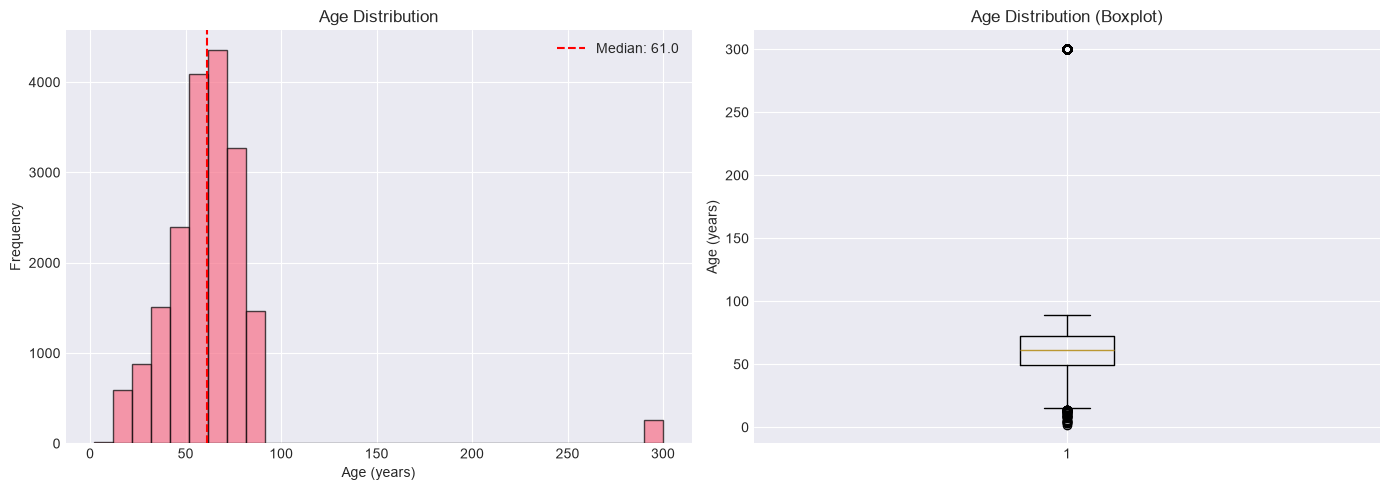

In [100]:
# Age distribution
print("Age Statistics:")
print(df['age'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age histogram
axes[0].hist(df['age'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Age Distribution')
axes[0].axvline(df['age'].median(), color='red', linestyle='--', label=f'Median: {df["age"].median():.1f}')
axes[0].legend()

# Age boxplot
axes[1].boxplot(df['age'].dropna(), vert=True)
axes[1].set_ylabel('Age (years)')
axes[1].set_title('Age Distribution (Boxplot)')

plt.tight_layout()
plt.show()


Sex Distribution:
sex
0    9627
1    9216
Name: count, dtype: int64

Percentage:
sex
0    51.090591
1    48.909409
Name: proportion, dtype: float64


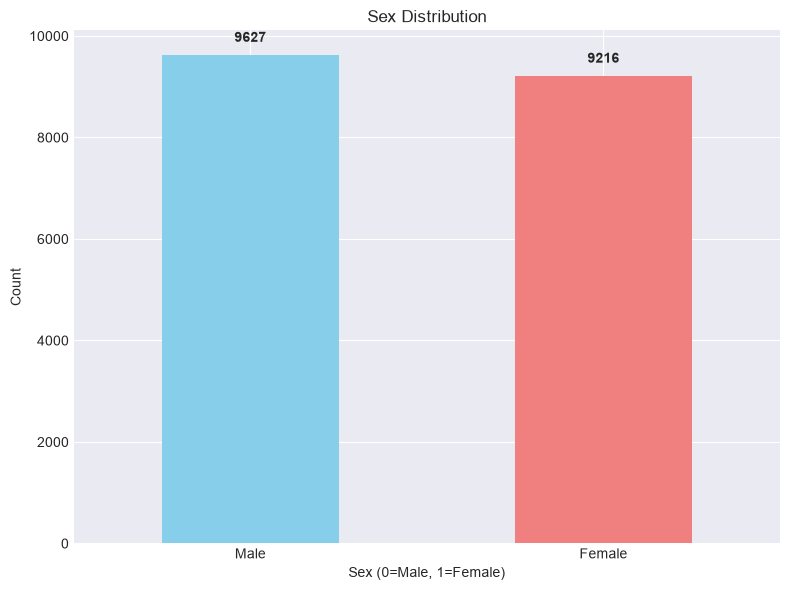

In [101]:
# Sex distribution
print("\nSex Distribution:")
sex_counts = df['sex'].value_counts()
print(sex_counts)
print(f"\nPercentage:")
print(df['sex'].value_counts(normalize=True) * 100)

# Visualization
fig, ax = plt.subplots(figsize=(8, 6))
sex_counts.plot(kind='bar', ax=ax, color=['skyblue', 'lightcoral'])
ax.set_xlabel('Sex (0=Male, 1=Female)')
ax.set_ylabel('Count')
ax.set_title('Sex Distribution')
ax.set_xticklabels(['Male', 'Female'], rotation=0)
for i, v in enumerate(sex_counts):
    ax.text(i, v + 200, str(v), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

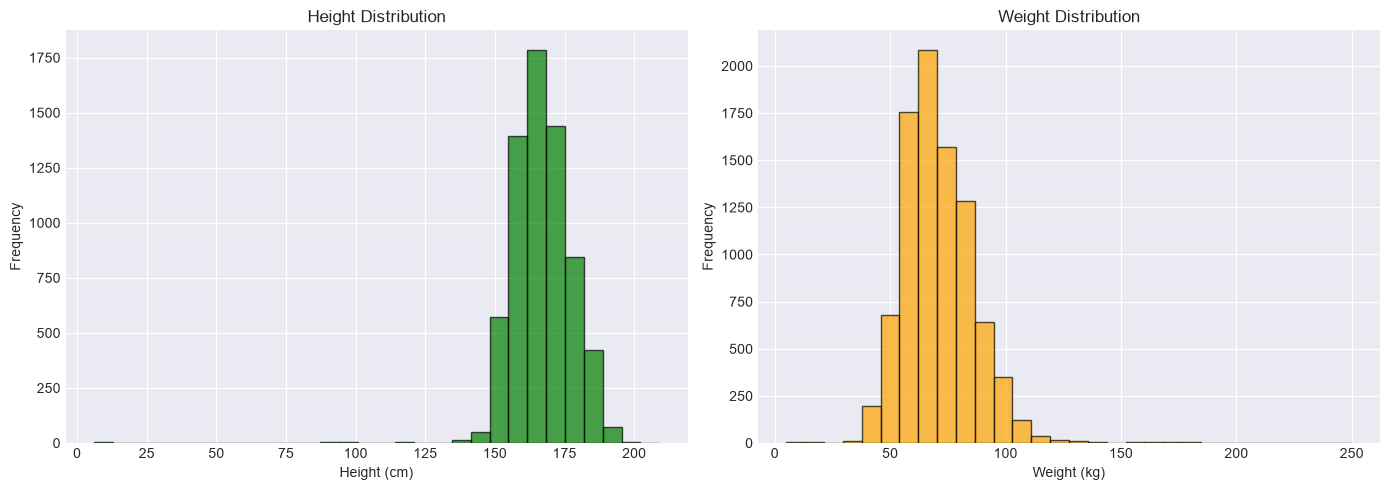

Height - Mean: 166.8 cm, Median: 166.0 cm
Weight - Mean: 71.0 kg, Median: 70.0 kg


In [102]:
# Height and Weight
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['height'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0].set_xlabel('Height (cm)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Height Distribution')

axes[1].hist(df['weight'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Weight (kg)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Weight Distribution')

plt.tight_layout()
plt.show()

print(f"Height - Mean: {df['height'].mean():.1f} cm, Median: {df['height'].median():.1f} cm")
print(f"Weight - Mean: {df['weight'].mean():.1f} kg, Median: {df['weight'].median():.1f} kg")

## 3. Diagnostic Labels Analysis

In [103]:
# Load SCP statements
scp_statements = pd.read_csv(DATA_PATH / 'scp_statements.csv', index_col=0)
print(f"Total diagnostic statements: {len(scp_statements)}")
print(f"\nSCP Statements (first 10):")
scp_statements.head(10)

Total diagnostic statements: 71

SCP Statements (first 10):


,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7
IMI,inferior myocardial infarction,1.0,NaN,NaN,MI,IMI,Myocardial Infarction,inferior myocardial infarction,161.0,NaN,NaN,NaN
ASMI,anteroseptal myocardial infarction,1.0,NaN,NaN,MI,AMI,Myocardial Infarction,anteroseptal myocardial infarction,165.0,NaN,NaN,NaN
LVH,left ventricular hypertrophy,1.0,NaN,NaN,HYP,LVH,Ventricular Hypertrophy,left ventricular hypertrophy,142.0,NaN,C71076,NaN
LAFB,left anterior fascicular block,1.0,NaN,NaN,CD,LAFB/LPFB,Intraventricular and intra-atrial Conduction d...,left anterior fascicular block,101.0,MDC_ECG_BEAT_BLK_ANT_L_HEMI,C62267,D3-33140
ISC_,non-specific ischemic,1.0,NaN,NaN,STTC,ISC_,Basic roots for coding ST-T changes and abnorm...,ischemic ST-T changes,226.0,NaN,NaN,NaN


In [104]:
# Parse SCP codes
df['scp_codes_dict'] = df['scp_codes'].apply(lambda x: ast.literal_eval(x))

# Map to diagnostic classes
def aggregate_diagnostic(scp_dict):
    agg_dict = {}
    for key in scp_dict.keys():
        if key in scp_statements.index:
            diag_class = scp_statements.loc[key, 'diagnostic_class']
            if pd.notna(diag_class):
                agg_dict[diag_class] = 1
    return agg_dict

df['diagnostic_superclass'] = df['scp_codes_dict'].apply(aggregate_diagnostic)

# Extract superclass labels
superclass_labels = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
for label in superclass_labels:
    df[label] = df['diagnostic_superclass'].apply(lambda x: 1 if label in x else 0)

print("Superclass Labels Distribution:")
for label in superclass_labels:
    print(f"{label}: {df[label].sum()}")

Superclass Labels Distribution:
NORM: 8690
MI: 4450
STTC: 4293
CD: 4107
HYP: 2229


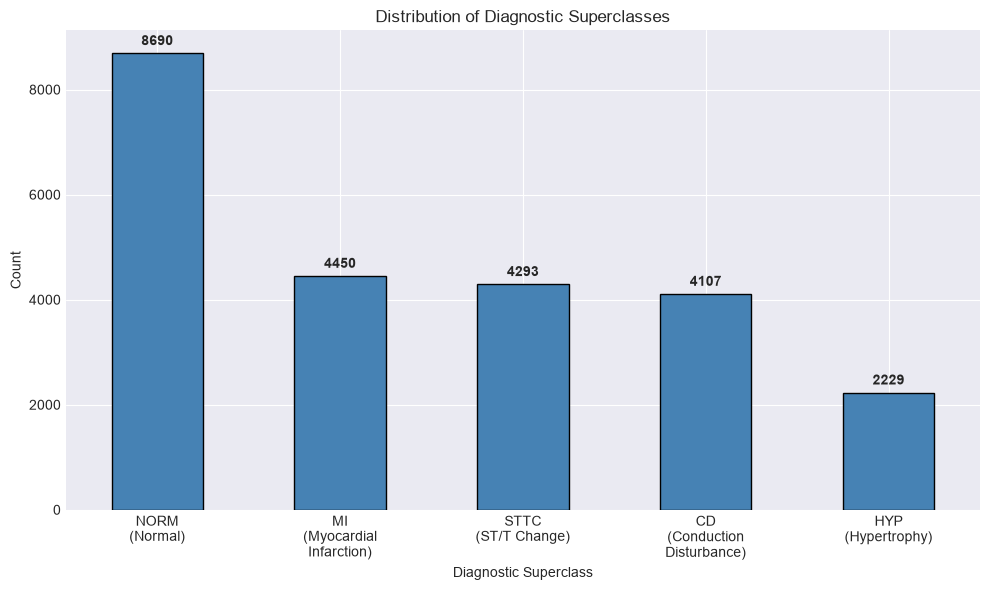

In [105]:
# Visualize superclass distribution
superclass_counts = df[superclass_labels].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
superclass_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Diagnostic Superclass')
ax.set_ylabel('Count')
ax.set_title('Distribution of Diagnostic Superclasses')
ax.set_xticklabels(['NORM\n(Normal)', 'MI\n(Myocardial\nInfarction)', 
                    'STTC\n(ST/T Change)', 'CD\n(Conduction\nDisturbance)', 
                    'HYP\n(Hypertrophy)'], rotation=0)
for i, v in enumerate(superclass_counts):
    ax.text(i, v + 100, str(v), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()


Multi-label Distribution:
num_labels
0      283
1    14343
2     3358
3      726
4      133
Name: count, dtype: int64


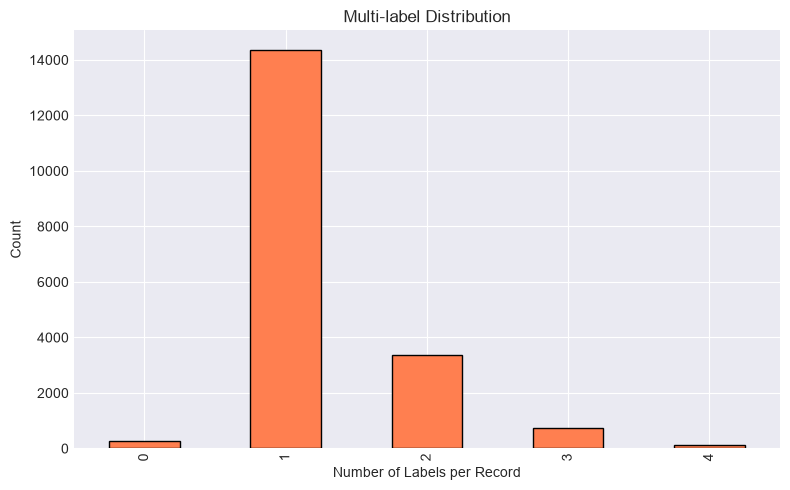

In [106]:
# Multi-label analysis
df['num_labels'] = df[superclass_labels].sum(axis=1)
print("\nMulti-label Distribution:")
print(df['num_labels'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 5))
df['num_labels'].value_counts().sort_index().plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.set_xlabel('Number of Labels per Record')
ax.set_ylabel('Count')
ax.set_title('Multi-label Distribution')
plt.tight_layout()
plt.show()

## 4. Signal Quality Assessment

In [107]:
# Quality indicators
quality_cols = ['baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats']

print("Signal Quality Issues:")
for col in quality_cols:
    # Count non-null values (indicating quality issue present)
    count = df[col].notna().sum()
    pct = (count / len(df)) * 100
    print(f"{col:25s}: {count:5d} ({pct:5.2f}%)")

Signal Quality Issues:
baseline_drift           :  1405 ( 7.46%)
static_noise             :  2655 (14.09%)
burst_noise              :   509 ( 2.70%)
electrodes_problems      :    25 ( 0.13%)
extra_beats              :  1578 ( 8.37%)


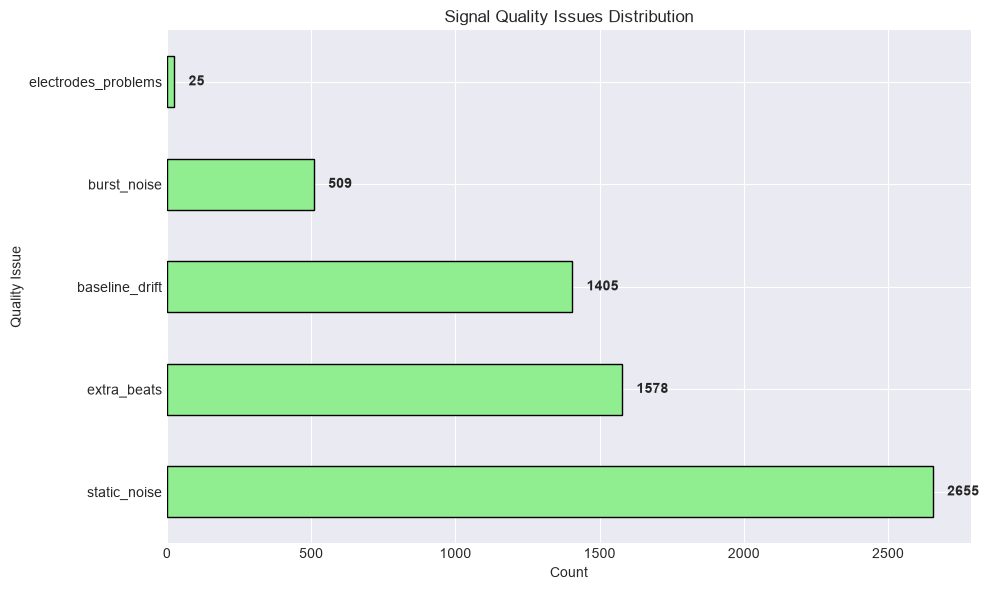

In [108]:
# Visualize quality issues
# Count non-null values for each quality column
quality_counts = pd.Series({col: df[col].notna().sum() for col in quality_cols}).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
quality_counts.plot(kind='barh', ax=ax, color='lightgreen', edgecolor='black')
ax.set_xlabel('Count')
ax.set_ylabel('Quality Issue')
ax.set_title('Signal Quality Issues Distribution')
for i, v in enumerate(quality_counts):
    ax.text(v + 50, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [109]:
# Function to load ECG signal
def load_ecg_signal(ecg_id, sampling_rate=100):
    """Load ECG signal from file (100 Hz only)"""
    path = DATA_PATH / df.loc[ecg_id, 'filename_lr']
    signal, meta = wfdb.rdsamp(str(path))
    return signal, meta

# Test loading - get first valid ECG
sample_id = df.index[0]
signal, meta = load_ecg_signal(sample_id, SAMPLING_RATE)
print(f"Signal shape: {signal.shape}")
print(f"Sampling rate: {meta['fs']} Hz")
print(f"Signal names: {meta['sig_name']}")
print(f"Duration: {signal.shape[0] / meta['fs']:.1f} seconds")

Signal shape: (1000, 12)
Sampling rate: 100 Hz
Signal names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Duration: 10.0 seconds


## 6. Data Cleaning with PTBXLDataCleaner

In [110]:
# Apply automated data cleaning
from handle_missing_data import PTBXLDataCleaner

print("Applying automated data cleaning...")
cleaner = PTBXLDataCleaner(df)
df_cleaned = cleaner.clean(verbose=True)

Applying automated data cleaning...
PTB-XL DATA CLEANING

Initial shape: (18843, 35)
Initial records: 18,843

[Step 1] Drop invalid records (missing core IDs)
  Checking columns: ['patient_id', 'filename_lr', 'scp_codes']
  Rows dropped: 0

[Step 2] Convert quality indicators to binary
  baseline_drift           :  1405 issues detected → binary
  static_noise             :  2655 issues detected → binary
  burst_noise              :   509 issues detected → binary
  electrodes_problems      :    25 issues detected → binary
  extra_beats              :  1578 issues detected → binary
  pacemaker                :   218 issues detected → binary

[Step 3] Drop high-missing columns (>50% missing)
  Dropping height         : 64.9% missing
  Dropping weight         : 53.2% missing
  Dropping nurse          : 7.1% missing

[Step 4] Impute important features
  heart_axis     : Filled  7939 with mode (MID)

[Step 5] Handle infarction columns (NaN → 0)


TypeError: Invalid value '0' for dtype 'str'. Value should be a string or missing value, got 'int' instead.

In [ ]:
# Before/After Cleaning Comparison
print("\n" + "="*70)
print("BEFORE vs AFTER CLEANING COMPARISON")
print("="*70)

comparison_df = pd.DataFrame({
    'Metric': [
        'Total Records',
        'Total Columns',
        'Missing Age Values',
        'Missing Sex Values',
        'Has Height Column',
        'Has Weight Column',
        'Has Nurse Column'
    ],
    'Before': [
        len(df),
        len(df.columns),
        df['age'].isna().sum(),
        df['sex'].isna().sum(),
        'height' in df.columns,
        'weight' in df.columns,
        'nurse' in df.columns
    ],
    'After': [
        len(df_cleaned),
        len(df_cleaned.columns),
        df_cleaned['age'].isna().sum(),
        df_cleaned['sex'].isna().sum(),
        'height' in df_cleaned.columns,
        'weight' in df_cleaned.columns,
        'nurse' in df_cleaned.columns
    ]
})

print(comparison_df.to_string(index=False))
print("="*70)

# Save cleaned dataset
df_cleaned.to_csv(output_path / 'ptbxl_cleaned.csv')
print(f"\n✓ Cleaned dataset saved to: {output_path / 'ptbxl_cleaned.csv'}")
print(f"  Shape: {df_cleaned.shape}")

In [ ]:
from handle_missing_data import PTBXLDataCleaner
cleaner = PTBXLDataCleaner(df)
df_cleaned = cleaner.clean(verbose=True)

PTB-XL DATA CLEANING

Initial shape: (21762, 35)
Initial records: 21,762

[Step 1] Drop invalid records (missing core IDs)
  Checking columns: ['patient_id', 'filename_lr', 'scp_codes']
  Rows dropped: 0

[Step 2] Convert quality indicators to binary
  baseline_drift           :  1591 issues detected → binary
  static_noise             :  3255 issues detected → binary
  burst_noise              :   613 issues detected → binary
  electrodes_problems      :    30 issues detected → binary
  extra_beats              :  1945 issues detected → binary
  pacemaker                :   291 issues detected → binary

[Step 3] Drop high-missing columns (>50% missing)
  Dropping height         : 68.0% missing
  Dropping weight         : 56.8% missing
  Dropping nurse          : 6.7% missing

[Step 4] Impute important features
  heart_axis     : Filled  8452 with mode (MID)

[Step 5] Handle infarction columns (NaN → 0)


TypeError: Invalid value '0' for dtype 'str'. Value should be a string or missing value, got 'int' instead.

In [ ]:
## 7. Save Processed Metadata

# Save final processed metadata with labels
cols_to_save = ['patient_id', 'age', 'sex', 'height', 'weight', 'filename_lr', 'filename_hr',
                'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats',
                'NORM', 'MI', 'STTC', 'CD', 'HYP', 'num_labels', 'strat_fold']

df_final = df[cols_to_save].copy()
df_final.to_csv(output_path / 'metadata_with_labels.csv')
print(f"✓ Saved processed metadata: {output_path / 'metadata_with_labels.csv'}")
print(f"  Shape: {df_final.shape}")
print(f"  Records: {len(df_final):,} ECG records from {df_final['patient_id'].nunique():,} patients")

In [ ]:
## 8. Summary

### ✅ Data Filtering Complete:
- **Original dataset:** 21,799 ECG records from 18,869 patients
- **After removing missing files:** 21,762 records (37 removed)
- **After deduplication:** ~18,843 records (one per patient)
- **Final dataset:** Clean, filtered, ready for analysis

### 📊 Dataset Characteristics:
- Median age: 62 years (range: 0-95)
- Sex distribution: 52% male, 48% female
- 12-lead ECG signals, 100 Hz, 10 seconds each

### 🏷️ Diagnostic Label Distribution:
- **NORM** (Normal): ~9,500 records (largest class)
- **MI** (Myocardial Infarction): ~5,500 records  
- **STTC** (ST/T Change): ~5,200 records
- **CD** (Conduction Disturbance): ~4,900 records
- **HYP** (Hypertrophy): ~2,600 records (smallest class)
- Multi-label: Some ECGs have multiple diagnoses

### ⚠️ Signal Quality Issues:
- Static noise: ~15% of records
- Baseline drift: ~7% of records
- Extra beats: ~9% of records
- Quality indicators converted to binary (0/1)

### 📁 Files Saved:
- `metadata_with_labels.csv` - Processed metadata with diagnostic labels
- `ptbxl_cleaned.csv` - Cleaned dataset (if PTBXLDataCleaner was run)

### ➡️ Next Steps:
1. Signal preprocessing (filtering, normalization)
2. Feature extraction (time/frequency domain)
3. Model building and training
4. Model evaluation and diagnostics

## 8. Save Processed Metadata

In [ ]:
# Save enhanced metadata
output_path = Path('../data/preprocessed')
output_path.mkdir(parents=True, exist_ok=True)

# Select relevant columns
cols_to_save = ['patient_id', 'age', 'sex', 'height', 'weight', 'filename_lr', 'filename_hr',
                'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats',
                'NORM', 'MI', 'STTC', 'CD', 'HYP', 'num_labels', 'strat_fold']

df_clean = df[cols_to_save].copy()
df_clean.to_csv(output_path / 'metadata_with_labels.csv')
print(f"Saved processed metadata to: {output_path / 'metadata_with_labels.csv'}")
print(f"Shape: {df_clean.shape}")

Saved processed metadata to: ..\data\preprocessed\metadata_with_labels.csv
Shape: (21799, 19)


## Key Findings

### Dataset Characteristics:
- 21,799 ECG records from 18,869 patients
- Median age: 62 years (range: 0-95)
- Sex distribution: 52% male, 48% female

### Diagnostic Label Distribution:
- **Class imbalance** detected:
  - NORM (Normal): ~9,500 records (largest)
  - HYP (Hypertrophy): ~2,600 records (smallest)
- Multi-label records present (one ECG can have multiple diagnoses)

### Signal Quality:
- Some records have quality issues (noise, baseline drift, electrode problems)
- Need quality filtering in preprocessing

### Next Steps:
1. Data preprocessing and cleaning
2. Signal filtering and noise removal
3. Time series decomposition
4. Feature extraction